In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)
library(viridis)
library(cowplot)

### 1. Yule trees with one shift (sd)

In [3]:
n_edges = 30
n_branches = n_edges
n_tips = 16
shifts = 10^(seq(log10(1e-4),log10(1e4), len=10))

num_rep = 500

n_rows = length(shifts) * num_rep * n_edges

p_vals_PC_2 = data.table(
    p.value=numeric(n_rows), 
    shifts=character(n_rows),
    tree=numeric(n_rows), 
    branch.id=numeric(n_rows), 
    branch.importance=numeric(n_rows)
)

In [4]:
set.seed(19)
counter = 1

for (j in 1:500) {
    if (j %% 10 == 0) {message("Testing for tree: ", j)}
    yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
    yule_tree$root.edge=0

    G <- matrix(0, nrow = n_branches, ncol = n_tips)
    for (i in 1:n_branches) {
        node_needed = yule_tree$edge[i, 2]
        descendants = getDescendants(yule_tree, node_needed)
        descendants_needed = descendants[descendants <= n_tips]
        G[i, descendants_needed] = 1
    }

    sum_branch_lengths <- sum(yule_tree$edge.length)

    cov_matrices <- matrix(0, nrow = n_tips^2, ncol = n_branches + 1)
    # calculate the weighted variance-covariance matrix for each branch
    for (i in 1:n_branches) {
        branch <- G[i, ]
        weight <- yule_tree$edge.length[i]
        cov_matrix_branch <- outer(branch, branch) * weight
        cov_matrices[, i] <- as.vector(cov_matrix_branch)
    }

    # calculate the variance-covariance matrix for the whole tree
    cov_matrices[, n_branches + 1] <- rowSums(cov_matrices)
    cov_matrix_total <- matrix(cov_matrices[, n_branches + 1], nrow = n_tips, 
                               byrow = TRUE)

    # wrap the computations in a data frame
    cov_matrices <- as.data.frame(cov_matrices)
    colnames(cov_matrices) <- c(paste0("vcv_", 1:n_branches), "vcv_tot")

    # get the names for the covariance matrices for each branch
    cov_matrices_names <- colnames(cov_matrices)
    cov_matrices_names <- cov_matrices_names[-(n_branches + 1)]

    # calculate eigenvectors for the covariance matrix of the tree
    vs <- eigen(cov_matrix_total)$vectors
    lambdas <- eigen(cov_matrix_total)$values

    for (i in 1:n_tips) {
        matrix_name <- paste0("eigen_", i)
        cov_matrices[[matrix_name]] <- as.vector(outer(vs[, i], vs[, i]))
    }

    # initialize the branch contributions matrix
    branch_contributions <- matrix(0, nrow = n_branches, ncol = n_tips)

    # create the common part of the formula for regression in string format
    str_formula_common <- paste(cov_matrices_names, collapse = " + ")
    str_formula_common <- paste("~", str_formula_common, "- 1")

    # calculate the branch contributions to each of the dimensions
    for (i in 1:n_tips) {
        # complete the formula for regression in string format
        eigen_name <- paste0("eigen_", i)
        str_formula <- paste(eigen_name, str_formula_common)
        reg_formula <- as.formula(str_formula)

        # run the regression
        model <- lm(reg_formula, data = cov_matrices)
        coeffs <- as.vector(coef(model))
        branch_contributions[, i] <- coeffs
    }

    # wrap the branch contributions in a data frame
    branch_contributions <- as.data.frame(branch_contributions)
    colnames(branch_contributions) <- paste0("dim_", 1:n_tips)

    l2_sum_dim <- sqrt((as.matrix(branch_contributions)^2) %*% lambdas)
    l2_rank <- rank(-l2_sum_dim, ties.method = "first")

    for (i in 1:length(shifts)) {
        shift = shifts[i]
        shift = formatC(shift, format = "e", digits = 3)
    
        for (k in 1:n_edges) {
            e = yule_tree$edge[k,]
            rank = l2_rank[k]
            descendants = getDescendants(yule_tree, e[2])
            descendants_tips = descendants[descendants <= n_tips]

            BM = fastBM(yule_tree, 1, nsim=2)
            X = BM[,1]
            Y = BM[,2]
            
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            
            all_data = as.data.frame(tibble(X = X, Y = Y))
            rownames(all_data) = rownames(BM)

            cur_lm = phylolm(Y ~ X, data=all_data, phy=yule_tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
                    
            p_vals_PC_2[counter, `:=`("p.value" = cur_p, "shifts" = shift, "tree" = j,
                                      "branch.id" = k, "branch.rank" = rank)]

            counter = counter + 1
        }      
    }
}

Testing for tree: 10

Testing for tree: 20

Testing for tree: 30

Testing for tree: 40

Testing for tree: 50

Testing for tree: 60

Testing for tree: 70

Testing for tree: 80

Testing for tree: 90

Testing for tree: 100

Testing for tree: 110

Testing for tree: 120

Testing for tree: 130

Testing for tree: 140

Testing for tree: 150

Testing for tree: 160

Testing for tree: 170

Testing for tree: 180

Testing for tree: 190

Testing for tree: 200

Testing for tree: 210

Testing for tree: 220

Testing for tree: 230

Testing for tree: 240

Testing for tree: 250

Testing for tree: 260

Testing for tree: 270

Testing for tree: 280

Testing for tree: 290

Testing for tree: 300

Testing for tree: 310

Testing for tree: 320

Testing for tree: 330

Testing for tree: 340

Testing for tree: 350

Testing for tree: 360

Testing for tree: 370

Testing for tree: 380

Testing for tree: 390

Testing for tree: 400

Testing for tree: 410

Testing for tree: 420

Testing for tree: 430

Testing for tree: 44

In [5]:
p_vals_PC_summary_2 = p_vals_PC_2 %>% group_by(shifts, branch.rank) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_2$sd.shift = sqrt(as.numeric(p_vals_PC_summary_2$shifts))

p_vals_PC_summary_2 = as.data.table(p_vals_PC_summary_2) 
p_vals_PC_summary_2$shifts = factor(p_vals_PC_summary_2$shifts)

In [10]:
plot_shift_2 <- p_vals_PC_summary_2 %>% 
  ggplot(aes(branch.rank, FPR, group = sd.shift)) +
  geom_line(aes(color = log10(sd.shift)), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Rank of the branch") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
  scale_color_viridis_c(
    option = "viridis",          # choose viridis scheme
    direction = -1,              # reverse scale: higher = darker/bluer
    # breaks = c(2, 4, 6, 8, 10),  # tick marks
    # labels = paste("Line", c(2, 4, 6, 8, 10)), # custom labels
    name = "log(sd(shift))"            # colorbar title
  ) +
  guides(color = guide_colorbar(   
    title.hjust = 0.5,
    barwidth = 3.5,               # width of color bar
    barheight = 45              # height of color bar
  )) +
  theme(
    legend.title = element_text(size = 24),  # font for title
    legend.text  = element_text(size = 18) # font for ticks
  )

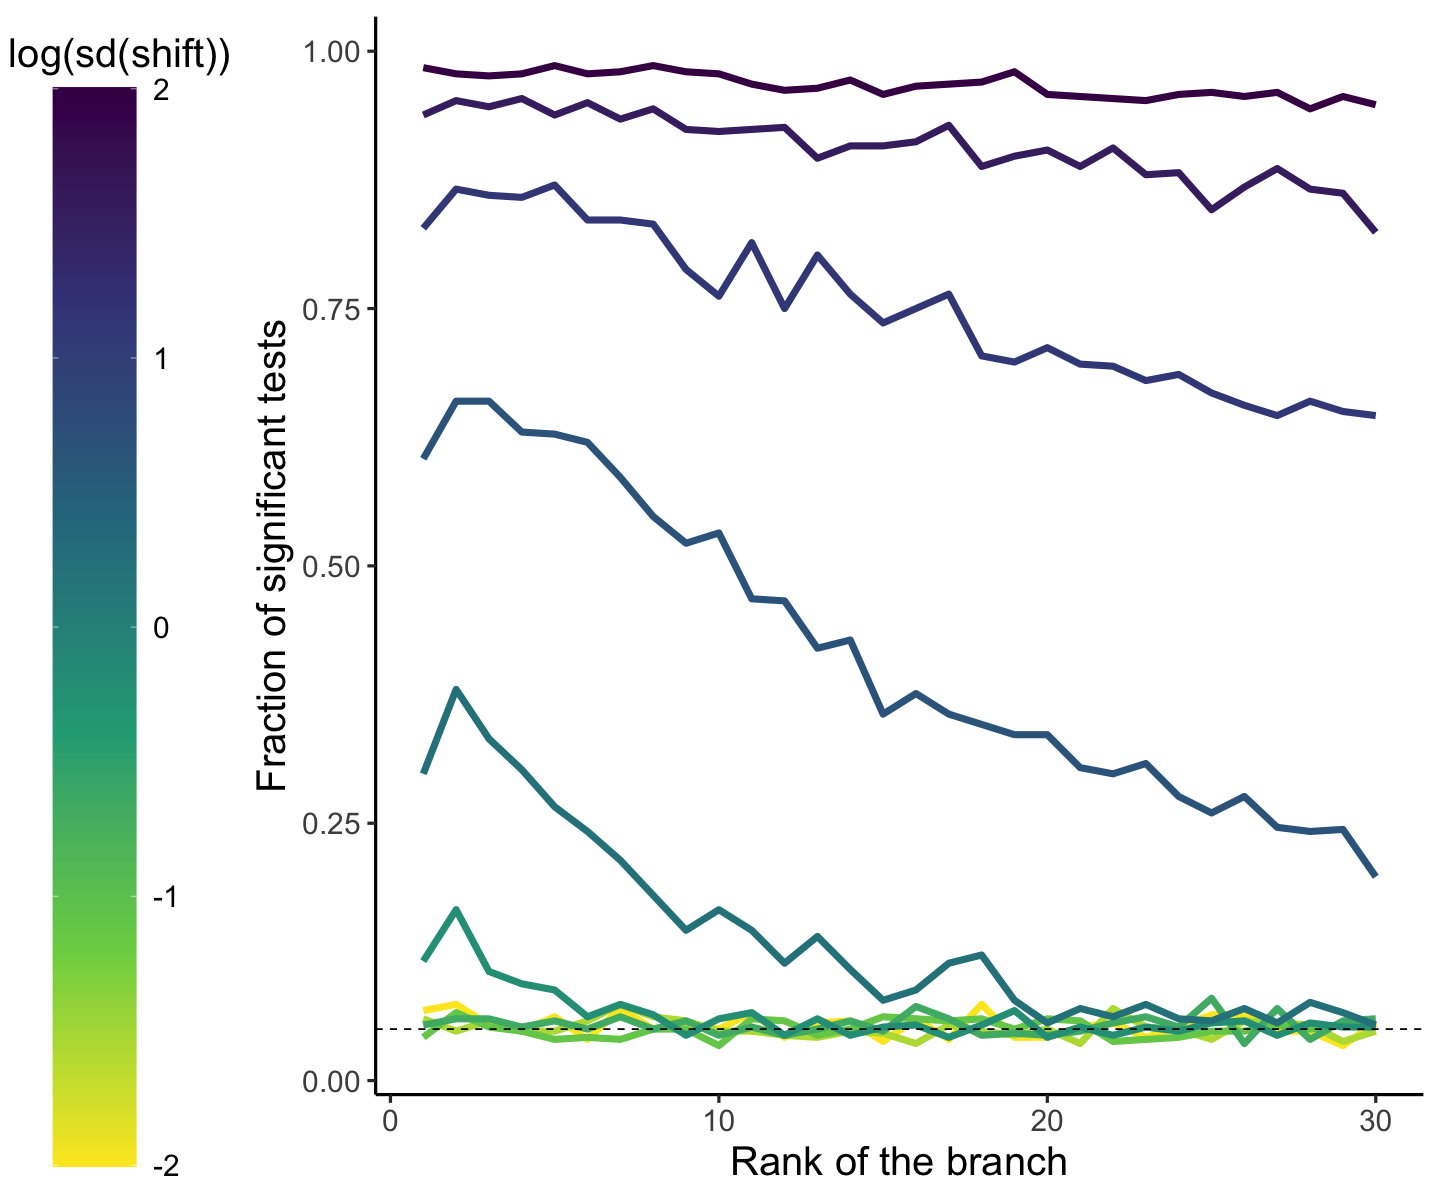

In [14]:
options(repr.plot.width = 12, repr.plot.height = 10)

legend_2 <- get_legend(plot_shift_2)

plot_shift_2_no_legend <- plot_shift_2 + theme(legend.position = "none")

final_plot_2 <- plot_grid(
  legend_2, plot_shift_2_no_legend,
  ncol = 2,
  rel_widths = c(2, 10),
  align = "none"
)

final_plot_2

ggsave("Figures_raw/Figure_4_alt_raw_1.pdf", final_plot_2, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_alt_raw_1.svg", final_plot_2, width = 11.5, height = 10)

### 2. Yule trees with one shift (mean)

In [12]:
n_edges = 30
n_branches = n_edges
n_tips = 16
shifts_2 = sqrt(shifts)

num_rep = 500

n_rows = length(shifts_2) * num_rep * n_edges

p_vals_PC_3 = data.table(
    p.value=numeric(n_rows), 
    shifts=character(n_rows),
    tree=numeric(n_rows), 
    branch.id=numeric(n_rows), 
    branch.importance=numeric(n_rows)
)

In [13]:
set.seed(19)
counter = 1

for (j in 1:500) {
    if (j %% 10 == 0) {message("Testing for tree: ", j)}
    yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
    yule_tree$root.edge=0

    G <- matrix(0, nrow = n_branches, ncol = n_tips)
    for (i in 1:n_branches) {
        node_needed = yule_tree$edge[i, 2]
        descendants = getDescendants(yule_tree, node_needed)
        descendants_needed = descendants[descendants <= n_tips]
        G[i, descendants_needed] = 1
    }

    sum_branch_lengths <- sum(yule_tree$edge.length)

    cov_matrices <- matrix(0, nrow = n_tips^2, ncol = n_branches + 1)
    # calculate the weighted variance-covariance matrix for each branch
    for (i in 1:n_branches) {
        branch <- G[i, ]
        weight <- yule_tree$edge.length[i]
        cov_matrix_branch <- outer(branch, branch) * weight
        cov_matrices[, i] <- as.vector(cov_matrix_branch)
    }

    # calculate the variance-covariance matrix for the whole tree
    cov_matrices[, n_branches + 1] <- rowSums(cov_matrices)
    cov_matrix_total <- matrix(cov_matrices[, n_branches + 1], nrow = n_tips, 
                               byrow = TRUE)

    # wrap the computations in a data frame
    cov_matrices <- as.data.frame(cov_matrices)
    colnames(cov_matrices) <- c(paste0("vcv_", 1:n_branches), "vcv_tot")

    # get the names for the covariance matrices for each branch
    cov_matrices_names <- colnames(cov_matrices)
    cov_matrices_names <- cov_matrices_names[-(n_branches + 1)]

    # calculate eigenvectors for the covariance matrix of the tree
    vs <- eigen(cov_matrix_total)$vectors
    lambdas <- eigen(cov_matrix_total)$values

    for (i in 1:n_tips) {
        matrix_name <- paste0("eigen_", i)
        cov_matrices[[matrix_name]] <- as.vector(outer(vs[, i], vs[, i]))
    }

    # initialize the branch contributions matrix
    branch_contributions <- matrix(0, nrow = n_branches, ncol = n_tips)

    # create the common part of the formula for regression in string format
    str_formula_common <- paste(cov_matrices_names, collapse = " + ")
    str_formula_common <- paste("~", str_formula_common, "- 1")

    # calculate the branch contributions to each of the dimensions
    for (i in 1:n_tips) {
        # complete the formula for regression in string format
        eigen_name <- paste0("eigen_", i)
        str_formula <- paste(eigen_name, str_formula_common)
        reg_formula <- as.formula(str_formula)

        # run the regression
        model <- lm(reg_formula, data = cov_matrices)
        coeffs <- as.vector(coef(model))
        branch_contributions[, i] <- coeffs
    }

    # wrap the branch contributions in a data frame
    branch_contributions <- as.data.frame(branch_contributions)
    colnames(branch_contributions) <- paste0("dim_", 1:n_tips)

    l2_sum_dim <- sqrt((as.matrix(branch_contributions)^2) %*% lambdas)
    l2_rank <- rank(-l2_sum_dim, ties.method = "first")

    for (i in 1:length(shifts_2)) {
        shift = shifts_2[i]
        shift = formatC(shift, format = "e", digits = 3)
    
        for (k in 1:n_edges) {
            e = yule_tree$edge[k,]
            rank = l2_rank[k]
            descendants = getDescendants(yule_tree, e[2])
            descendants_tips = descendants[descendants <= n_tips]

            BM = fastBM(yule_tree, 1, nsim=2)
            X = BM[,1]
            Y = BM[,2]
            
            X[descendants_tips] = X[descendants_tips] + shifts_2[i]
            Y[descendants_tips] = Y[descendants_tips] + shifts_2[i]
            
            all_data = as.data.frame(tibble(X = X, Y = Y))
            rownames(all_data) = rownames(BM)

            cur_lm = phylolm(Y ~ X, data=all_data, phy=yule_tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
                    
            p_vals_PC_3[counter, `:=`("p.value" = cur_p, "shifts" = shift, "tree" = j,
                                      "branch.id" = k, "branch.rank" = rank)]

            counter = counter + 1
        }      
    }
}

Testing for tree: 10

Testing for tree: 20

Testing for tree: 30

Testing for tree: 40

Testing for tree: 50

Testing for tree: 60

Testing for tree: 70

Testing for tree: 80

Testing for tree: 90

Testing for tree: 100

Testing for tree: 110

Testing for tree: 120

Testing for tree: 130

Testing for tree: 140

Testing for tree: 150

Testing for tree: 160

Testing for tree: 170

Testing for tree: 180

Testing for tree: 190

Testing for tree: 200

Testing for tree: 210

Testing for tree: 220

Testing for tree: 230

Testing for tree: 240

Testing for tree: 250

Testing for tree: 260

Testing for tree: 270

Testing for tree: 280

Testing for tree: 290

Testing for tree: 300

Testing for tree: 310

Testing for tree: 320

Testing for tree: 330

Testing for tree: 340

Testing for tree: 350

Testing for tree: 360

Testing for tree: 370

Testing for tree: 380

Testing for tree: 390

Testing for tree: 400

Testing for tree: 410

Testing for tree: 420

Testing for tree: 430

Testing for tree: 44

In [15]:
p_vals_PC_summary_3 = p_vals_PC_3 %>% group_by(shifts, branch.rank) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_PC_summary_3$mean.shift = as.numeric(p_vals_PC_summary_3$shifts)

p_vals_PC_summary_3 = as.data.table(p_vals_PC_summary_3) 
p_vals_PC_summary_3$shifts = factor(p_vals_PC_summary_3$shifts)

In [16]:
plot_shift_3 <- p_vals_PC_summary_3 %>% 
  ggplot(aes(branch.rank, FPR, group = mean.shift)) +
  geom_line(aes(color = log10(mean.shift)), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Rank of the branch") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 18), legend.text = element_text(size = 16)) + 
  scale_color_viridis_c(
    option = "magma",          # choose viridis scheme
    direction = -1,              # reverse scale: higher = darker/bluer
    # breaks = c(2, 4, 6, 8, 10),  # tick marks
    # labels = paste("Line", c(2, 4, 6, 8, 10)), # custom labels
    name = "log(shift)"            # colorbar title
  ) +
  guides(color = guide_colorbar(   
    title.hjust = 0.5,
    barwidth = 3.5,               # width of color bar
    barheight = 45              # height of color bar
  )) +
  theme(
    legend.title = element_text(size = 24),  # font for title
    legend.text  = element_text(size = 18) # font for ticks
  )

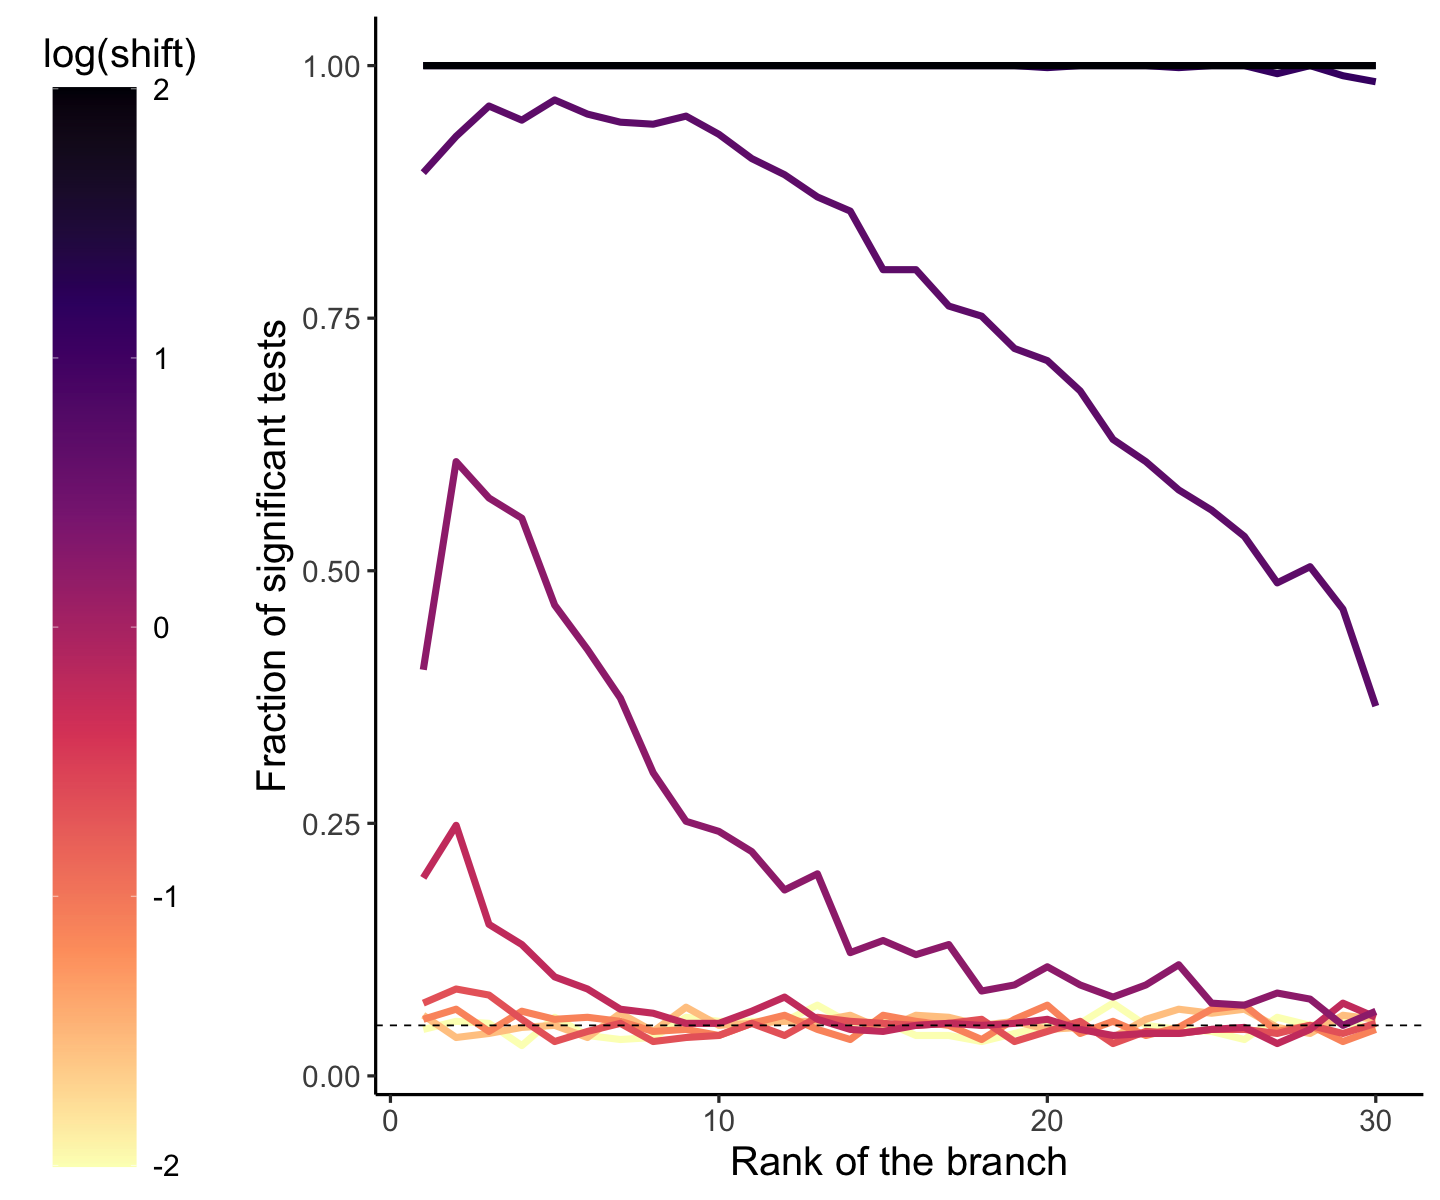

In [17]:
options(repr.plot.width = 12, repr.plot.height = 10)

legend_3 <- get_legend(plot_shift_3)

plot_shift_3_no_legend <- plot_shift_3 + theme(legend.position = "none")

final_plot_3 <- plot_grid(
  legend_3, plot_shift_3_no_legend,
  ncol = 2,
  rel_widths = c(2, 10),
  align = "none"
)

final_plot_3

ggsave("Figures_raw/Figure_4_alt_raw_2.pdf", final_plot_3, width = 11.5, height = 10)
ggsave("Figures_raw/Figure_4_alt_raw_2.svg", final_plot_3, width = 11.5, height = 10)